In [6]:
import pandas as pd

books = pd.read_csv(r"C:\Users\satis\Downloads\30 Day - SQL Practice Files- SD50\30 Day - SQL Practice Files\Books.csv")
customers = pd.read_csv(r"C:\Users\satis\Downloads\30 Day - SQL Practice Files- SD50\30 Day - SQL Practice Files\Customers.csv")
orders = pd.read_csv(r"C:\Users\satis\Downloads\30 Day - SQL Practice Files- SD50\30 Day - SQL Practice Files\Orders.csv")

from IPython.display import display

display(books.head())
display(customers.head())
display(orders.head())

,Book_ID,Title,Author,Genre,Published_Year,Price,Stock
0,1,Configurable modular throughput,Joseph Crane,Biography,1949,21.34,100
1,2,Persevering reciprocal knowledge user,Mario Moore,Fantasy,1971,35.80,19
2,3,Streamlined coherent initiative,Derrick Howard,Non-Fiction,1913,15.75,27
3,4,Customizable 24hour product,Christopher Andrews,Fiction,2020,43.52,8
4,5,Adaptive 5thgeneration encoding,Juan Miller,Fantasy,1956,10.95,16


,Customer_ID,Name,Email,Phone,City,Country
0,1,Deborah Griffith,balljoseph@wright-keith.net,1234567891,South Craigfort,Denmark
1,2,Crystal Clements,kimberlybennett@curtis.com,1234567892,East Derekberg,Nicaragua
2,3,Susan Fuller,beanmichael@burnett-stewart.net,1234567893,Austinbury,Equatorial Guinea
3,4,Jamie Ramirez,amandahood@warren.com,1234567894,Dianamouth,Slovenia
4,5,Marcus Murphy,connerjohn@yahoo.com,1234567895,Smithbury,Guinea-Bissau


,Order_ID,Customer_ID,Book_ID,Order_Date,Quantity,Total_Amount
0,1,84,169,2023-05-26,8,188.56
1,2,137,301,2023-01-23,10,216.60
2,3,216,261,2024-05-27,6,85.50
3,4,433,343,2023-11-25,7,301.21
4,5,14,431,2023-07-26,7,136.36


In [7]:
customers['Country'] = customers['Country'].str.strip()
print(customers['Country'].unique())
# Remove Extra Spaces

<StringArray>
[                         'Denmark',                        'Nicaragua',
                'Equatorial Guinea',                         'Slovenia',
                    'Guinea-Bissau',                           'Rwanda',
                       'Montenegro',                           'Israel',
                          'Somalia',                         'Cameroon',
 ...
                           'Jordan',                      'Philippines',
                           'Angola',                         'Cambodia',
                     'Cook Islands', 'Saint Vincent and the Grenadines',
                        'Singapore',                   'American Samoa',
                           'Latvia',                            'Haiti']
Length: 215, dtype: str


In [6]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])
print(orders.dtypes)
# Convert Date Column

Order_ID                 int64
Customer_ID              int64
Book_ID                  int64
Order_Date      datetime64[us]
Quantity                 int64
Total_Amount           float64
dtype: object


In [8]:
# Check Missing Values
print(orders.isnull().sum())

Order_ID        0
Customer_ID     0
Book_ID         0
Order_Date      0
Quantity        0
Total_Amount    0
dtype: int64


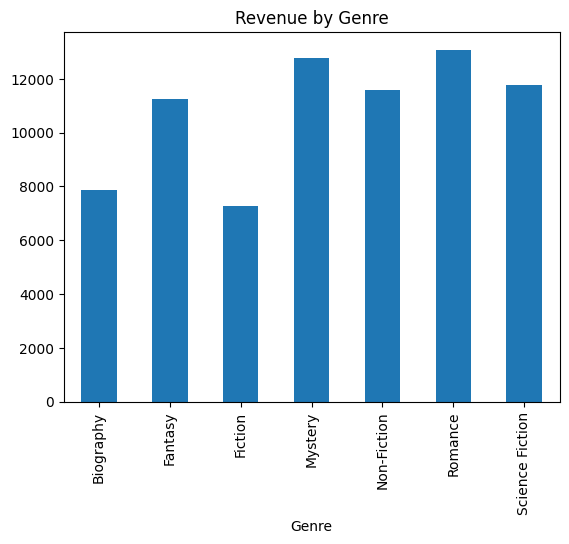

In [7]:
import matplotlib.pyplot as plt

df = orders.merge(books, on="Book_ID")

genre_sales = df.groupby("Genre")["Total_Amount"].sum()

genre_sales.plot(kind="bar")
plt.title("Revenue by Genre")
plt.show()

In [9]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

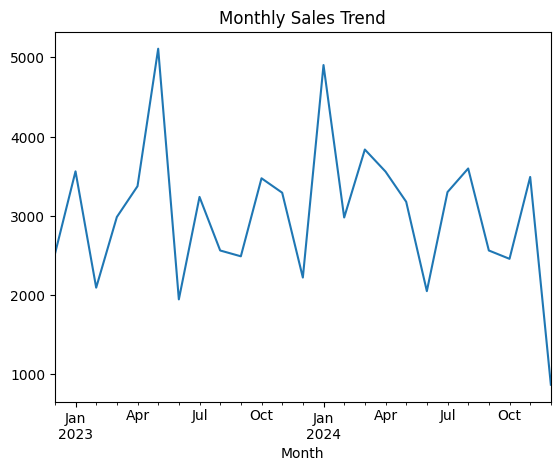

In [10]:
df['Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total_Amount'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

In [13]:
customer_spending = df.groupby("Customer_ID")["Total_Amount"].sum()

def segment(x):
    if x > 100:
        return "High Value"
    elif x > 50:
        return "Medium Value"
    else:
        return "Low Value"

segments = customer_spending.apply(segment)
print(segments.value_counts())

Total_Amount
High Value      226
Low Value        44
Medium Value     37
Name: count, dtype: int64
